# 7. Live Tutorial 2: Querying and Plotting Real NOMAD Data

Notebooks 1–5 built the *concepts* — FAIR metadata, EMMO, and NOMAD's data
model — using local Python so nothing depended on network access, and
Notebook 6 turned those concepts into a live, hands-on SQL/NoSQL
investigation of your own local data. This notebook is a second live
session, and the payoff specifically for NOMAD: we connect to the **real,
public NOMAD repository** at `nomad-lab.eu` and use it exactly the way you
would for a real project — searching, paginating, extracting numeric
properties, and plotting the results with the tools from Part I
(`pandas`, `matplotlib`, `seaborn`).

Read the explanation, run the cell, look at the output, then do the
linked exercise before moving on. Every cell that talks to the network is
guarded so the notebook degrades gracefully (with a clear message) if you
lose your connection mid-session — re-run the guard cell in Section 7.1 to
reconnect.

**Topics**
1. Do you need an API key? (short answer: not for this)
2. Your first request: a URL you can paste into a browser
3. A structured search with `POST /entries/query`, and your first plot
4. Understanding query semantics (`all` vs `any`)
5. Paginating through thousands of results
6. From a search hit to one full record
7. Numeric properties done right: band gaps and unit conversion
8. Personal Access Tokens: NOMAD's API key, and what it unlocks
9. Summary: anonymous vs. authenticated

## 7.1 Do You Need an API Key?

**No — not for reading published data.** NOMAD's central repository is
built around open science: anyone can query and download *published*
entries anonymously, with no account, no registration, and no API key. You
only need credentials for things that are inherently personal or private —
uploading data, seeing your own unpublished entries, or acting as a
specific user. Section 7.8 covers that; everything before it works for
absolutely anyone.

Run the cell below once now. It checks connectivity and sets a flag,
`NOMAD_ONLINE`, that every later cell checks before making a request — if
your connection drops partway through the session, just re-run this cell
to pick up again without re-running everything above it.

In [1]:
import requests

BASE_URL = 'https://nomad-lab.eu/prod/v1/api/v1'

def check_nomad_online(attempts=3, timeout=30):
    """The very first request to a server can be slow (cold connection,
    DNS, TLS handshake) — retry a couple of times before giving up."""
    for _ in range(attempts):
        try:
            r = requests.get(f'{BASE_URL}/info', timeout=timeout)
            if r.status_code == 200:
                return True
        except requests.exceptions.RequestException:
            pass
    return False

NOMAD_ONLINE = check_nomad_online()

if NOMAD_ONLINE:
    print('Connected to NOMAD — no API key was sent, and none was required.')
else:
    print('Could not reach NOMAD right now. Check your connection and re-run this cell')
    print('before continuing — every later cell depends on NOMAD_ONLINE.')

Connected to NOMAD — no API key was sent, and none was required.


## 7.2 Your First Request: Just a URL

The simplest NOMAD search is a plain `GET` request with query parameters —
exactly the kind of URL you could paste into a browser address bar and get
JSON back. `requests.get` does the same thing from Python. Let's ask for
entries containing iron (the same element used as the running example in
Notebooks 1–4, and in the Materials Project examples in the
[course project guide](../06_project/project.md) — the same chemical
system, two different repositories).

In [2]:
if NOMAD_ONLINE:
    r = requests.get(f'{BASE_URL}/entries', params={
        'results.material.elements': 'Fe',
        'page_size': 3,
    })
    print('Status code:', r.status_code)
    print('You could paste this straight into a browser:')
    print(' ', r.json()['pagination']['page_url'])
    print()
    print('Total entries containing iron in all of NOMAD:',
          f"{r.json()['pagination']['total']:,}")

Status code: 200
You could paste this straight into a browser:
  https://nomad-lab.eu/prod/v1/api/v1/entries?results.material.elements=Fe&page_size=3

Total entries containing iron in all of NOMAD: 759,233


## 7.3 A Structured Search with `POST /entries/query`

The `GET /entries` endpoint above is fine for a single filter, but real
searches usually need several conditions and specific fields back —
NOMAD's `POST /entries/query` endpoint takes a JSON **request body**
instead of URL parameters, which scales much better. It has three parts,
which you will reuse for the rest of this notebook:

- **`query`** — which entries to match (like a `WHERE` clause)
- **`pagination`** — how many results per page (`page_size`), and where to
  resume (Section 7.5)
- **`required`** — which fields to actually return (`required.include`) —
  without this, NOMAD returns a large default set of fields you usually
  don't need

Let's search for materials containing both iron and oxygen, and pull back
just the fields needed to build a small table: the formula and the crystal
system.

In [3]:
import pandas as pd

if NOMAD_ONLINE:
    query = {
        'query': {
            'results.material.elements': ['Fe', 'O'],
        },
        'pagination': {'page_size': 50},
        'required': {
            'include': [
                'entry_id',
                'results.material.chemical_formula_reduced',
                'results.material.symmetry.crystal_system',
            ]
        },
    }
    r = requests.post(f'{BASE_URL}/entries/query', json=query)
    print('Status code:', r.status_code)
    result = r.json()
    print('Total Fe-O entries in NOMAD:', f"{result['pagination']['total']:,}")
    print('Entries returned this page:', len(result['data']))

Status code: 200
Total Fe-O entries in NOMAD: 48,741
Entries returned this page: 50


### From JSON to a DataFrame to a Plot

Each hit in `result['data']` is a nested dictionary — exactly the shape
Notebooks 1 and 4 had you build by hand. Flattening nested JSON into a flat
table is one of the single most common real-world data-handling tasks, and
it is just a list comprehension over dictionary access, the same pattern
Part I, Notebook 3 (pandas) used for building DataFrames from records.

In [4]:
if NOMAD_ONLINE:
    rows = []
    for entry in result['data']:
        mat = entry.get('results', {}).get('material', {})
        rows.append({
            'entry_id':       entry['entry_id'],
            'formula':        mat.get('chemical_formula_reduced'),
            'crystal_system': mat.get('symmetry', {}).get('crystal_system'),
        })

    df_feo = pd.DataFrame(rows)
    print(df_feo.head(10))
    print()
    print('Missing crystal_system (not every entry has full symmetry data):',
          df_feo['crystal_system'].isna().sum(), '/', len(df_feo))

                       entry_id          formula crystal_system
0  --4Tz9cNrqRCfi4VSIv3SMzYNGd_           FeO7P2     monoclinic
1  --BVaNqRoGysH9uT0RCIbjuyRV5U        Cr3Fe2O12      triclinic
2  --ErPNNAPdNaz113PtGg4Aea8xEQ  C72FeH44N6O16U2           None
3  --HZrISlofqr8C1W0wWuPLEEFSLe        FeMoO6Sr2          cubic
4  --UWIIVuUzXxO6ohF0bUAR1co6SZ            Fe4O4          cubic
5  --hRM6fRWogvxygyl9HIT3oMkmXR          Ba3FeO5     tetragonal
6  --jIt82ioQ70cDpXKgKQ6nMPpvkt           BiFeO3           None
7  --kSFBxgDBRnC5DHkG-dnhYnMfzq          F3Fe4O5      triclinic
8  --l53thMRxzfX6rdDT66taWedWIM           FeO3Rh          cubic
9  --xiVBGQ0Kh7da_RvtRqr3Y7VemV       Fe2O2P2Sm2     tetragonal

Missing crystal_system (not every entry has full symmetry data): 5 / 50


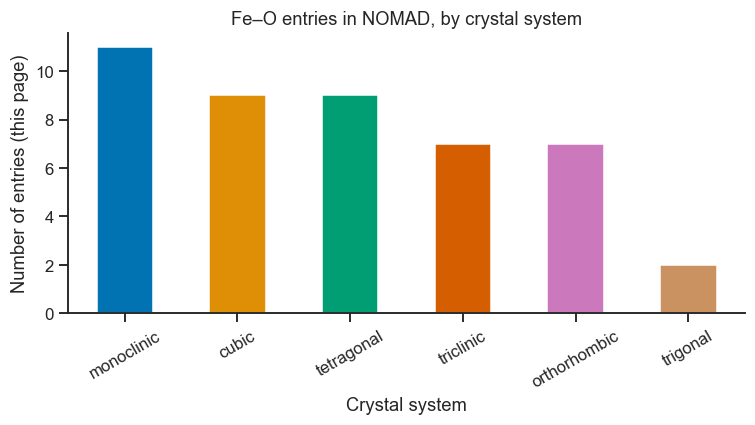

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='ticks', palette='colorblind')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})

if NOMAD_ONLINE:
    counts = df_feo['crystal_system'].value_counts()

    fig, ax = plt.subplots(figsize=(7, 4))
    counts.plot(kind='bar', ax=ax, color=sns.color_palette('colorblind'))
    ax.set_xlabel('Crystal system')
    ax.set_ylabel('Number of entries (this page)')
    ax.set_title('Fe–O entries in NOMAD, by crystal system')
    ax.tick_params(axis='x', rotation=30)
    sns.despine(ax=ax)
    plt.tight_layout()
    plt.show()

**Checkpoint / Exercise 1**: Change the element list in Section 7.3 from
`['Fe', 'O']` to a binary system of your choice (e.g. `['Ti', 'O']` or
`['Zn', 'O']`), re-run Sections 7.3–7.3's plotting cell, and compare the
crystal-system distribution to iron oxide's. Which system has more
structural diversity?

## 7.4 Query Semantics: `all` vs. `any`

One subtlety worth getting right before you trust a query's results:
`'results.material.elements': ['Fe', 'O']` means *"contains **all** of Fe
**and** O, possibly plus other elements too"* — not *"is exactly Fe and O
and nothing else."* You can see this in the formulas returned above (some
have three or more elements). To restrict to *exactly* binary Fe–O
compounds, add a second condition on the element **count**, which is
exactly what an `AND` of two conditions in the `query` dict gives you.

In [6]:
if NOMAD_ONLINE:
    query_exact_binary = {
        'query': {
            'results.material.elements': ['Fe', 'O'],
            'results.material.n_elements': 2,     # exactly two elements — no ternaries
        },
        'pagination': {'page_size': 50},
        'required': {
            'include': ['entry_id', 'results.material.chemical_formula_reduced'],
        },
    }
    r = requests.post(f'{BASE_URL}/entries/query', json=query_exact_binary)
    result_binary = r.json()
    formulas = sorted({e['results']['material']['chemical_formula_reduced']
                        for e in result_binary['data']})
    print(f"{result_binary['pagination']['total']:,} strictly binary Fe-O entries in total.")
    print('Distinct formulas on this page:', formulas)

2,364 strictly binary Fe-O entries in total.
Distinct formulas on this page: ['Fe11O12', 'Fe2O3', 'Fe2O6', 'Fe3O4', 'Fe4O4', 'Fe8O9', 'FeO', 'FeO2', 'FeO3']


## 7.5 Paginating Through Thousands of Results

`page_size` caps how many entries come back in one response — NOMAD will
not hand you all 48,000+ Fe–O entries at once. To collect more than one
page, follow the cursor NOMAD gives you back:
`pagination['next_page_after_value']`, passed as `page_after_value` on the
next request — the same cursor-based pattern most large web APIs use.
The loop below collects five pages (250 entries) into a single DataFrame,
sleeping briefly between requests to stay a polite, well-behaved client of
a shared public service — a good habit for *any* API, not just NOMAD's.

In [7]:
import json
import time

def fetch_pages(query_body, n_pages=5, page_size=50, sleep_s=0.2):
    """Collect n_pages of results into a single list of entries."""
    all_entries = []
    body = json.loads(json.dumps(query_body))    # deep copy, safe to mutate
    body['pagination'] = {'page_size': page_size}
    for _ in range(n_pages):
        r = requests.post(f'{BASE_URL}/entries/query', json=body)
        r.raise_for_status()
        page = r.json()
        all_entries.extend(page['data'])
        after = page['pagination'].get('next_page_after_value')
        if after is None:
            break                                  # ran out of results
        body['pagination']['page_after_value'] = after
        time.sleep(sleep_s)
    return all_entries


if NOMAD_ONLINE:
    query_binary_feo = {
        'query': {'results.material.elements': ['Fe', 'O'], 'results.material.n_elements': 2},
        'required': {'include': ['entry_id', 'results.material.chemical_formula_reduced',
                                  'results.material.symmetry.space_group_number']},
    }
    entries_500 = fetch_pages(query_binary_feo, n_pages=5, page_size=50)
    print(f'Collected {len(entries_500)} entries across 5 pages.')

    rows = [{
        'formula': e['results']['material'].get('chemical_formula_reduced'),
        'space_group_number': e['results']['material'].get('symmetry', {}).get('space_group_number'),
    } for e in entries_500]
    df_binary = pd.DataFrame(rows)
    print(df_binary['space_group_number'].describe())

Collected 250 entries across 5 pages.
count    239.000000
mean     189.380753
std       69.537800
min        1.000000
25%      177.000000
50%      225.000000
75%      225.000000
max      225.000000
Name: space_group_number, dtype: float64


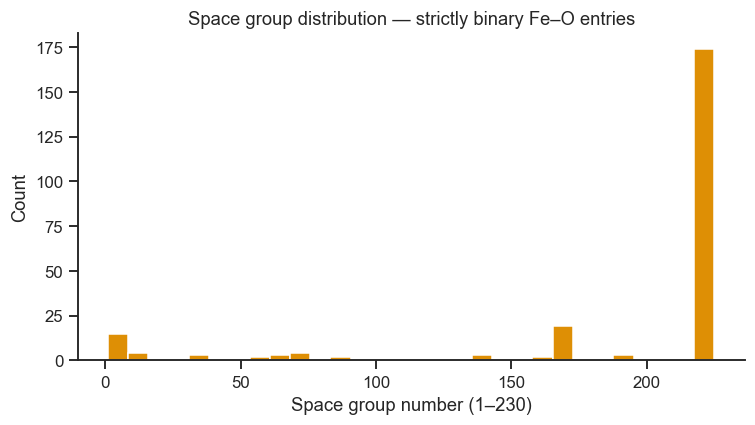

11 of 250 entries have no symmetry data — dropped from the histogram, same as Part I's df.dropna().


In [8]:
if NOMAD_ONLINE:
    fig, ax = plt.subplots(figsize=(7, 4))
    df_binary['space_group_number'].dropna().plot(
        kind='hist', bins=30, ax=ax, color=sns.color_palette('colorblind')[1])
    ax.set_xlabel('Space group number (1–230)')
    ax.set_ylabel('Count')
    ax.set_title('Space group distribution — strictly binary Fe–O entries')
    sns.despine(ax=ax)
    plt.tight_layout()
    plt.show()
    print(f"{df_binary['space_group_number'].isna().sum()} of {len(df_binary)} entries "
          f"have no symmetry data — dropped from the histogram, same as Part I's df.dropna().")

**Exercise 2**: Rewrite `fetch_pages` (or call it differently) to keep
paging until you have collected **at least 300** binary Fe–O entries,
instead of a fixed `n_pages=5`. Hint: use a `while` loop (Part I, Notebook 1,
Section 1.3) instead of a `for` loop, and check `len(all_entries)` at the
top of each iteration.

## 7.6 From a Search Hit to One Full Record

A search result gives you a summary. To see *everything* NOMAD has for one
specific material, `GET /entries/{entry_id}` — no query body needed. This
is the single-record view: the same "drill into one entry" idea as
Notebook 4's `nomad_style_entry`, now against real, published data.

In [9]:
if NOMAD_ONLINE:
    # pick one real entry_id from the 500 collected in Section 7.5
    one_entry_id = entries_500[0]['entry_id']

    r = requests.get(f'{BASE_URL}/entries/{one_entry_id}')
    material = r.json()['data']['results']['material']

    print('Material name:      ', material.get('material_name'))
    print('Formula:             ', material.get('chemical_formula_descriptive'))
    print('Structural type:     ', material.get('structural_type'))
    print('Compound type:       ', material.get('compound_type'))
    print('Functional type(s):  ', material.get('functional_type'))
    print('Space group:         ', material.get('symmetry', {}).get('space_group_symbol'))

Material name:       Iron(II) Oxide
Formula:              Fe4O4
Structural type:      bulk
Compound type:        ['oxide']
Functional type(s):   ['antiferromagnet AFM', 'intermediate valence', 'nonmetal', 'semiconductor']
Space group:          Fm-3m


## 7.7 Numeric Properties Done Right: Band Gaps

Here is a genuinely important, easy-to-miss lesson about working with a
real search API: **not every field you can filter on is a field you can
directly retrieve from a search result.** NOMAD's search index knows
*whether* an entry has a computed band gap (fast to check, at any scale),
but the actual numeric value sometimes has to be fetched from that entry's
**full archive** individually. This is a completely normal pattern for
large data infrastructures — the search index is optimised for filtering
millions of records, not for handing back every deeply nested number — and
it means the correct workflow has two steps:

1. **Search** for entries that *have* the property you want (fast, scales
   to any number of entries)
2. **Fetch** the full archive for each matching entry to get the actual
   value (slower — do this only for the entries you actually kept)

Step 1 uses `results.properties.available_properties`, a field listing
which property categories an entry actually has computed.

In [10]:
if NOMAD_ONLINE:
    query_has_gap = {
        'query': {
            'results.material.elements': ['Zn', 'O'],
            'results.material.n_elements': 2,
            'results.properties.available_properties': 'electronic.band_structure_electronic.band_gap',
        },
        'pagination': {'page_size': 20},
        'required': {
            'include': ['entry_id', 'results.material.chemical_formula_reduced',
                        'results.material.symmetry.crystal_system'],
        },
    }
    r = requests.post(f'{BASE_URL}/entries/query', json=query_has_gap)
    result_gap = r.json()
    print(f"{result_gap['pagination']['total']:,} Zn-O entries have a computed band gap "
          f"(out of the total Zn-O entries in NOMAD).")
    candidates = result_gap['data']
    print(f'Using the first {len(candidates)} as candidates for Step 2.')

1,121 Zn-O entries have a computed band gap (out of the total Zn-O entries in NOMAD).
Using the first 20 as candidates for Step 2.


### Step 2: Fetch Each Archive, Convert Units, Build a Table

`POST /entries/{entry_id}/archive/query` returns the full archive for one
entry, optionally restricted to just the section you need (keeps the
response small). NOMAD stores physical quantities in **SI base units**
internally — energy in **joules**, not electronvolts — so every band gap
needs converting before it means anything to a materials scientist. This
is the same unit-discipline lesson as Part I, Notebook 1's molar-mass
calculation, just applied to data coming from a server instead of values
you typed in yourself.

$$E_{\text{gap}}~[\text{eV}] = \frac{E_{\text{gap}}~[\text{J}]}{1.602176634 \times 10^{-19}}$$

In [11]:
import numpy as np

J_TO_EV = 1 / 1.602176634e-19    # CODATA elementary charge, in coulombs

def fetch_band_gap_eV(entry_id):
    """Fetch one entry's archive and return its first band gap in eV, or NaN."""
    body = {'required': {'results': {'properties': {'electronic': {'band_gap': '*'}}}}}
    r = requests.post(f'{BASE_URL}/entries/{entry_id}/archive/query', json=body)
    if r.status_code != 200:
        return np.nan
    band_gaps = (r.json().get('data', {}).get('archive', {})
                 .get('results', {}).get('properties', {})
                 .get('electronic', {}).get('band_gap', []))
    return band_gaps[0]['value'] * J_TO_EV if band_gaps else np.nan


if NOMAD_ONLINE:
    rows = []
    for entry in candidates:
        mat = entry['results']['material']
        rows.append({
            'entry_id':       entry['entry_id'],
            'formula':        mat.get('chemical_formula_reduced'),
            'crystal_system': mat.get('symmetry', {}).get('crystal_system'),
            'band_gap_eV':    fetch_band_gap_eV(entry['entry_id']),
        })
        time.sleep(0.1)                              # stay polite — one request per iteration

    df_gap = pd.DataFrame(rows)
    print(df_gap)
    print()
    print(f"{df_gap['band_gap_eV'].notna().sum()} of {len(df_gap)} candidates actually "
          f"yielded a value — 'available' doesn't always mean 'present in the exact "
          f"section this query asked for'. Real APIs are like this; always check.")

                        entry_id formula crystal_system  band_gap_eV
0   -0mvu5hr9nwhfgdOnDpoRYjYyYOY     OZn          cubic     0.710400
1   -DrgCOn5qnufoBsVLsUk9siZibYF   O4Zn4          cubic          NaN
2   -EvIwv71QwOBa5q8bnz94EOKTyU5   O4Zn4          cubic     0.480480
3   -HbeP0aVfKzn_1Tj3MooCDJlh7W9   O4Zn4          cubic     0.000000
4   -VbZr_Bj5mqQtbOXaB6fn90yqODQ   O4Zn4          cubic          NaN
5   -b3lD-N_GIYU7q12M9jqrNZ2WHCw     OZn      hexagonal     0.788280
6   -doTw-zFC1Xeouh8K56CzZEf4grp   O4Zn4          cubic     0.570571
7   -eGA4Wr9l7HWtpSmI0EswygNlOKn   O4Zn4          cubic          NaN
8   -fKzxesjnMzSYCrsJGvQobLAUhri   O4Zn4          cubic          NaN
9   -kXXgRtyrVlCVYbbGgLQ93aKdLZ0   O4Zn4          cubic     0.480480
10  0-iLUmskMfIi4LgN0Y1E1tJYNf7p   O4Zn4          cubic          NaN
11  02EkbIH-9_n6bs3EotF0-G1XHRJ7   O4Zn4          cubic          NaN
12  03m9DWb0_uVUOA0ZsEljKGyQfwa6   O8Zn8          cubic     1.117750
13  0BKjKS9uvR0Xx_szRJwXCXBDFLE5  

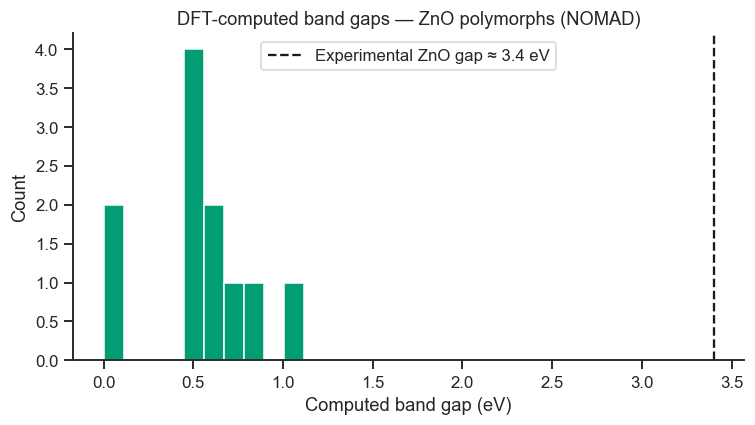

Mean computed gap: 0.52 eV vs. experimental ≈ 3.4 eV.
This gap-underestimation is a well-known artefact of standard DFT functionals
(GGA/LDA) — a good reminder that a *computed* property and an *experimental*
property are not interchangeable without checking the method (Part III onward
will give you the statistical tools to quantify exactly this kind of systematic bias).


In [12]:
if NOMAD_ONLINE:
    gaps = df_gap['band_gap_eV'].dropna()

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(gaps, bins=10, color=sns.color_palette('colorblind')[2], edgecolor='white')
    ax.axvline(3.4, color='k', ls='--', lw=1.5, label='Experimental ZnO gap ≈ 3.4 eV')
    ax.set_xlabel('Computed band gap (eV)')
    ax.set_ylabel('Count')
    ax.set_title('DFT-computed band gaps — ZnO polymorphs (NOMAD)')
    ax.legend()
    sns.despine(ax=ax)
    plt.tight_layout()
    plt.show()

    print(f'Mean computed gap: {gaps.mean():.2f} eV vs. experimental ≈ 3.4 eV.')
    print('This gap-underestimation is a well-known artefact of standard DFT functionals')
    print('(GGA/LDA) — a good reminder that a *computed* property and an *experimental*')
    print('property are not interchangeable without checking the method (Part III onward')
    print('will give you the statistical tools to quantify exactly this kind of systematic bias).')

**Exercise 3**: Repeat Section 7.7 for a different oxide system (e.g.
`['Ti', 'O']` for TiO₂ or `['Ga', 'N']` for GaN — not an oxide, but the
same query pattern). Look up that material's experimental band gap and add
it as a second `axvline` for comparison, the same way ZnO's was added above.

**Exercise 4**: `fetch_band_gap_eV` silently returns `NaN` on any non-200
response. Modify it to also `print` a warning with the entry_id and status
code when that happens, so failures are visible instead of silent — this
is the same defensive-but-transparent error handling principle used by the
`validate_entry` function in Notebook 4.

## 7.8 Personal Access Tokens: NOMAD's API Key

Everything above worked with zero credentials because it only *read*
*published* data. An **API key** — NOMAD calls it a **Personal Access
Token (PAT)** — becomes necessary the moment you want to act *as
yourself*: see your own unpublished uploads, or (in a NOMAD Oasis, Notebook
4) work with your institution's private data.

**Getting one** (you need a free NOMAD account first — register at
`nomad-lab.eu`):
1. Log in on the NOMAD website.
2. Open your account/profile menu and find **"Personal access tokens"**
   (or equivalent account-settings page for API access).
3. Create a new token, giving it a name and an expiry. **Copy the raw token
   immediately — it is shown only once.**

Programmatically, the same thing happens via two calls: `POST /auth/token`
with your username and password gets you a short-lived login token, which
you then use once to call `POST /auth/pats` and mint a long-lived PAT — the
GUI does exactly this for you, which is why it is the easier path for most
people.

Once you have a token, you send it in the `Authorization` header on every
request: `Authorization: Bearer <your_token>`. The cell below looks for a
token in the `NOMAD_TOKEN` variable; if you have one, paste it in and
re-run the cell. If you don't, leave it as-is — the rest of this section
still runs and shows you exactly what changes.

In [13]:
NOMAD_TOKEN = ''   # paste your Personal Access Token here, or leave blank

HEADERS = {'Authorization': f'Bearer {NOMAD_TOKEN}'} if NOMAD_TOKEN else {}

if NOMAD_TOKEN:
    print('A token is set — requests below will be authenticated as you.')
else:
    print('No token set — requests below will run anonymously, and the "protected"')
    print('calls are expected to fail with 401 Unauthorized. That failure is the point:')
    print('it shows you exactly which endpoints need a key and which do not.')

No token set — requests below will run anonymously, and the "protected"
calls are expected to fail with 401 Unauthorized. That failure is the point:
it shows you exactly which endpoints need a key and which do not.


### Testing the Token: `GET /users/me`

This endpoint answers one question: *"who does the server think I am?"* —
a good sanity check right after getting a token, before using it for
anything else.

In [14]:
if NOMAD_ONLINE:
    r = requests.get(f'{BASE_URL}/users/me', headers=HEADERS)
    print('Status code:', r.status_code)
    if r.status_code == 200:
        me = r.json()
        print('Authenticated as:', me.get('name'), f"<{me.get('email')}>")
    else:
        print('Response:', r.json())

Status code: 401
Response: {'detail': 'Authentication required.'}


### What a Key Actually Unlocks: `GET /uploads`

`/uploads` lists **your own** uploads — including anything unpublished,
which by definition no anonymous request can ever see. Compare the status
code here with every request earlier in this notebook.

In [15]:
if NOMAD_ONLINE:
    r = requests.get(f'{BASE_URL}/uploads', headers=HEADERS)
    print('Status code:', r.status_code)
    if r.status_code == 200:
        uploads = r.json()['data']
        print(f'You have {len(uploads)} upload(s).')
    elif r.status_code == 401:
        print('401 Unauthorized — exactly what every anonymous request in this notebook')
        print('avoided until now, because /uploads is about *your* private data, not the')
        print('public repository. This is the FAIR "Accessible" principle (Notebook 1) in')
        print('action: public data is openly accessible, private data is not, by design.')

Status code: 401
401 Unauthorized — exactly what every anonymous request in this notebook
avoided until now, because /uploads is about *your* private data, not the
public repository. This is the FAIR "Accessible" principle (Notebook 1) in
action: public data is openly accessible, private data is not, by design.


## 7.9 Summary: Anonymous vs. Authenticated

| Capability | Anonymous | With a Personal Access Token |
|---|---|---|
| Search published entries (`/entries/query`) | ✅ | ✅ |
| Fetch a published entry's full archive | ✅ | ✅ |
| See your own unpublished uploads (`/uploads`) | ❌ 401 | ✅ |
| Upload new data | ❌ | ✅ |
| See who you're authenticated as (`/users/me`) | ❌ 401 | ✅ |

Everything in Sections 7.1–7.7 — which is most of what a materials
scientist analysing *published* data needs — never required a key at all.
Keep that distinction in mind before assuming an API needs registration:
check what you are actually trying to do first.

---
## Exercises

*(Exercises 1–4 are inline above, at the point in the notebook where you
have the context to attempt them. The following are additional practice
beyond the core session.)*

5. **New element system, full pipeline**: Pick a binary compound system
   you are curious about (check its experimental band gap online first, so
   you have something to compare against). Repeat Sections 7.3, 7.5, and
   7.7 for it: a crystal-system bar chart, a paginated space-group
   histogram (≥150 entries), and a band-gap histogram with an `axvline` for
   the experimental value.

6. **Scatter plot across two properties**: Using the 500-entry
   `entries_500` collected in Section 7.5, also collect
   `results.material.n_elements` for each entry (add it to `required.include`
   and rebuild the DataFrame). Make a scatter plot of `space_group_number`
   vs. `n_elements`, colouring points by whether `n_elements == 2` — does
   symmetry correlate with compositional complexity in this dataset?

7. **Robust pagination**: `fetch_pages` in Section 7.5 has no error
   handling — if one request in the middle of a long loop fails (network
   hiccup, server error), the whole function crashes and you lose every
   page already fetched. Rewrite it to catch `requests.exceptions.RequestException`
   per request, retry once, and otherwise skip that page and continue,
   printing a warning (the same defensive pattern as Exercise 4).

8. **Connect it to Notebook 1**: Take the flat `df_binary` DataFrame from
   Section 7.5. Write a `fair_check`-style record (Notebook 1, Section 1.6)
   documenting this dataset: identifier, title, creator, `created` date,
   licence, and a `keywords` list — then save both the DataFrame (as CSV)
   and the FAIR record (as JSON) to disk, exactly the way Notebook 5's
   capstone did for the synthetic tool-steel dataset. You have now built a
   FAIR archive from *real, live* repository data, start to finish.